In [9]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("./csv/[한국에너지공단] 자동차 연비표시제도 정보_utf8.csv")
df.head(5)

,순번,년도,모델명,제조사,유종,배기량,변속형식,복합연비,등급,CO2배출량,1회충전주행거리,고속도로연비,도심연비,자동차종류,유형
0,seq,yr,model_nm,makr,oiltp,dsplvl,trmss_fom,cmpnd_fuel,grd,co2_dchr_qy,onet_chrstn_drvng_dstc,expresway_fuel,cntrofgr_fuel,car_knd,type
1,1,2019,쏘나타(LF)개조차 2.0LPI MT (15),현대,LPG,1999,수동6,9.5,4등급,136.0,NaN,NaN,NaN,NaN,NaN
2,2,2019,BMW X3 xDrive20d,BMW,경유,1995,자동8,12.1,3등급,162.0,NaN,NaN,NaN,NaN,NaN
3,3,2019,레인지로버 이보크 2.0D,랜드로버,경유,1999,자동9,12.3,3등급,156.0,NaN,NaN,NaN,NaN,NaN
4,4,2019,GV70 2.5T-GDI 2WD 21인치,현대,휘발유,2497,자동8,9.8,4등급,173.0,NaN,NaN,NaN,NaN,NaN


In [12]:
df[df['유형'] == None].count()

순번          0
년도          0
모델명         0
제조사         0
유종          0
배기량         0
변속형식        0
복합연비        0
등급          0
CO2배출량      0
1회충전주행거리    0
고속도로연비      0
도심연비        0
자동차종류       0
유형          0
dtype: int64

In [5]:
df1 = df.dropna

In [7]:
df.shape

(16443, 15)

In [19]:
df.columns

Index(['업체명', '모델명', '연료', '변속형식', '차량형식', '자동차 종류', '표시연비', '도심주행연비',
       '고속도로연비', 'CO2배출량(g/km)', '1회충전주행거리(km)', '배기량', '등급', '출시연도',
       '예상 연간유류비'],
      dtype='object')

In [22]:
df = pd.read_excel("./csv/자동차표시연비 목록.xlsx")
df1 = df.drop(columns=['1회충전주행거리(km)'],)
df1.head(5)

,업체명,모델명,연료,변속형식,차량형식,자동차 종류,표시연비,도심주행연비,고속도로연비,CO2배출량(g/km),배기량,등급,출시연도,예상 연간유류비
0,ASTON MARTIN LAGONDA LIMITED,DB12 S Coupe,휘발유,자동,내연기관,승용차,6.7,5.7,8.6,264,3982,5등급,2026,3761843
1,현대,팰리세이드(LX3) 2.5T-GDI AWD 8AT 7인 20인치 XRT,휘발유,자동,내연기관,승용차,8.3,7.4,9.7,205,1598,5등급,2026,3036669
2,현대,팰리세이드(LX3) 2.5T-GDI 2WD 8AT 7인 20인치 XRT,휘발유,자동,내연기관,승용차,8.9,7.9,10.8,189,2497,5등급,2026,2831949
3,페라리,페라리 아말피,휘발유,자동,내연기관,승용차,8.2,7.2,9.8,215,3855,5등급,2026,3073701
4,ASTON MARTIN LAGONDA LIMITED,Vantage S Roadster,휘발유,자동,내연기관,승용차,7.5,6.4,9.4,236,3982,5등급,2026,3360580


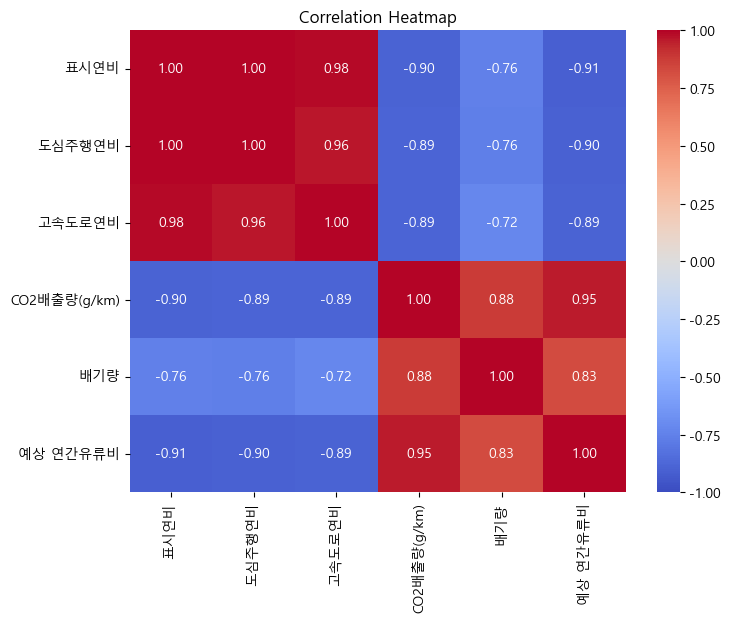

In [35]:
import seaborn as sns
import seaborn_cjk
import matplotlib.pyplot as plt

seaborn_cjk.patch()


corr = df1[['표시연비', '도심주행연비', '고속도로연비', 'CO2배출량(g/km)', '배기량', '예상 연간유류비']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df2 = df1[['표시연비', '도심주행연비', '고속도로연비', 'CO2배출량(g/km)', '배기량', '예상 연간유류비']].dropna()
df2.head()

,표시연비,도심주행연비,고속도로연비,CO2배출량(g/km),배기량,예상 연간유류비
0,6.7,5.7,8.6,264,3982,3761843
1,8.3,7.4,9.7,205,1598,3036669
2,8.9,7.9,10.8,189,2497,2831949
3,8.2,7.2,9.8,215,3855,3073701
4,7.5,6.4,9.4,236,3982,3360580


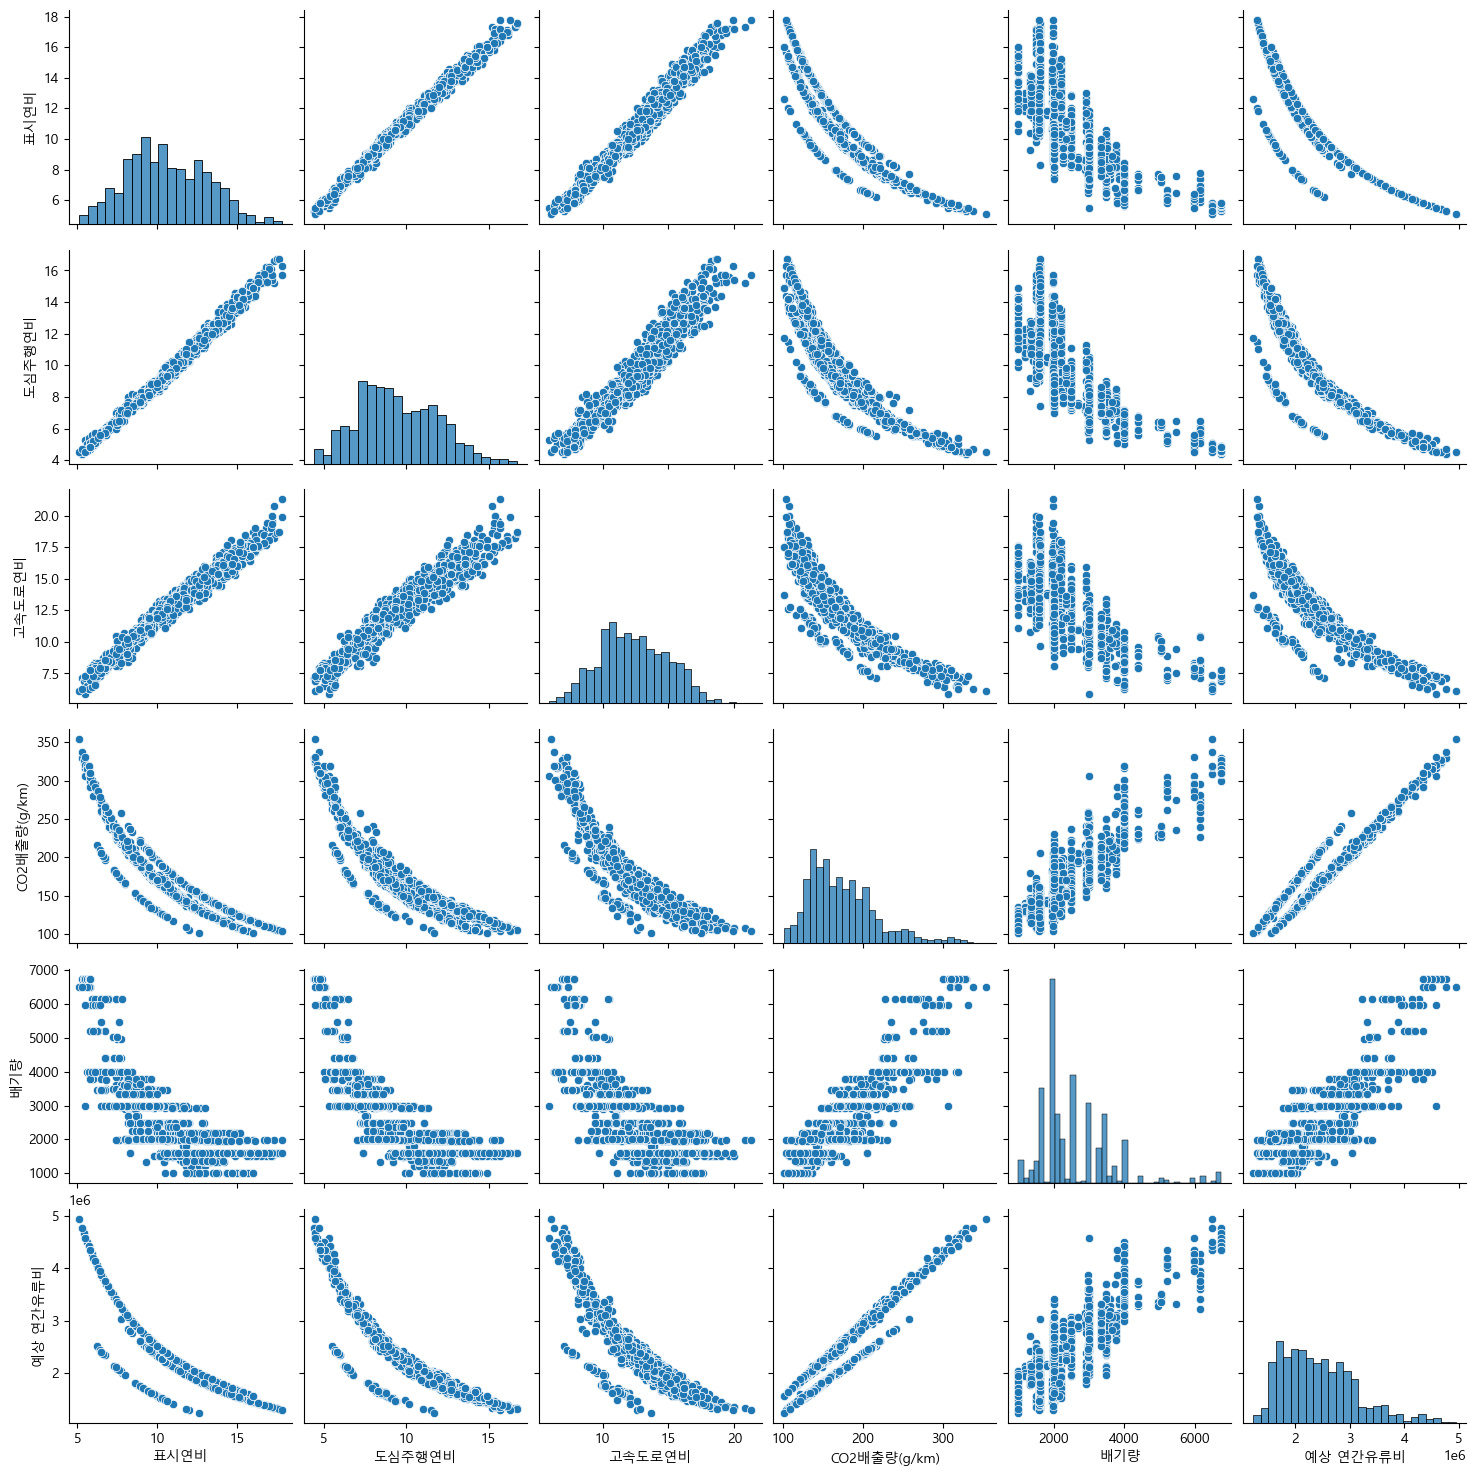

In [42]:
sns.pairplot(data=df2)
plt.show()

In [62]:
x = df2[['고속도로연비', '도심주행연비','표시연비', 'CO2배출량(g/km)', ]]
y = df2['예상 연간유류비']

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=10)

lr1 = LinearRegression()
lr1.fit(x_train, y_train)
print('pre poly:', lr1.score(x_train, y_train) , lr1.score(x_test, y_test))

poly = PolynomialFeatures(degree=4, include_bias=False)
poly.fit(x_train)
x_train_poly = poly.transform(x_train)
x_test_poly = poly.transform(x_test)

lr2 = LinearRegression()
lr2.fit(x_train_poly, y_train)
print('after poly:',lr2.score( x_train_poly, y_train), lr2.score(x_test_poly, y_test))

lasso = Lasso()
lasso.fit(x_train_poly, y_train)
print("after lasso:", lasso.score(x_train_poly, y_train), lasso.score(x_test_poly, y_test))

pre poly: 0.9275903243546675 0.9269219966721643
after poly: 0.9997060299479829 0.999688739640396
after lasso: 0.9963829009407658 0.9969962432415382


c:\Users\kst\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.545e+12, tolerance: 8.536e+10
  model = cd_fast.enet_coordinate_descent(


In [72]:
lr1.predict([[8.2, 7.2, 9.8,  215]])

c:\Users\kst\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2257713.29296548])

In [66]:
df2.head()

,표시연비,도심주행연비,고속도로연비,CO2배출량(g/km),배기량,예상 연간유류비
0,6.7,5.7,8.6,264,3982,3761843
1,8.3,7.4,9.7,205,1598,3036669
2,8.9,7.9,10.8,189,2497,2831949
3,8.2,7.2,9.8,215,3855,3073701
4,7.5,6.4,9.4,236,3982,3360580
